# 02 Feature Engineering

This notebook documents the **Data Preparation / Feature Engineering** phase.

Final feature scope:
- Raw transaction features.
- Historical graph features.
- Rolling temporal graph features.
- Advanced centrality and motif/cycle-proxy features.
- Snapshot PageRank/community features were tested but not selected as the final feature set.
- Split-safe node2vec embeddings are trained later in the modeling notebook/script because they require a chronological train graph.

The final selected model uses:

`raw + historical + rolling + advanced graph + split-safe node2vec embeddings`.

In [1]:
from pathlib import Path
import sys

# Works when launched from repository root or from notebooks/.
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.load_data import load_transactions, save_parquet
from src.features.tabular_features import add_basic_transaction_features, make_model_matrix
from src.features.historical_graph_features import add_historical_graph_features
from src.features.rolling_graph_features import add_rolling_graph_features
from src.features.advanced_graph_features import add_temporal_centrality_and_motif_features

try:
    from src.features.snapshot_graph_features import add_snapshot_pagerank_community_features
except Exception:
    add_snapshot_pagerank_community_features = None
    print("snapshot_graph_features module not available; snapshot experiment can still be reported from saved CSVs.")

PROJECT_ROOT: /home/acer/dev/aml-graph-dm


## 1. Configuration

`REBUILD_FEATURES = False` prevents accidental multi-hour feature rebuilding. Set it to `True` only when you want to regenerate `data/processed/hi_small_features.parquet`.

In [2]:
DATASET_NAME = "HI-Small"
RAW_PATH = RAW_DIR / f"{DATASET_NAME}_Trans.csv"
OUT_PATH = PROCESSED_DIR / "hi_small_features.parquet"

NROWS = 2_000_000
REBUILD_FEATURES = False
USE_SNAPSHOT_GRAPH = False  # tested separately; final model does not use it

print("RAW_PATH:", RAW_PATH)
print("OUT_PATH:", OUT_PATH)
print("NROWS:", NROWS)
print("REBUILD_FEATURES:", REBUILD_FEATURES)
print("USE_SNAPSHOT_GRAPH:", USE_SNAPSHOT_GRAPH)

RAW_PATH: /home/acer/dev/aml-graph-dm/data/raw/HI-Small_Trans.csv
OUT_PATH: /home/acer/dev/aml-graph-dm/data/processed/hi_small_features.parquet
NROWS: 2000000
REBUILD_FEATURES: False
USE_SNAPSHOT_GRAPH: False


## 2. Build or load processed feature table

The safe default is to load the existing processed feature table. To rebuild from raw data, change `REBUILD_FEATURES=True`.

In [3]:
if OUT_PATH.exists() and not REBUILD_FEATURES:
    print("Processed feature table already exists. Loading:", OUT_PATH)
    df_features = pd.read_parquet(OUT_PATH)
elif RAW_PATH.exists():
    print("Loading raw data...")
    df = load_transactions(RAW_PATH, nrows=NROWS)

    print("Adding raw transaction features...")
    df_features = add_basic_transaction_features(df)

    print("Adding historical leakage-safe graph features...")
    df_features = add_historical_graph_features(df_features)

    print("Adding rolling-window temporal graph features...")
    df_features = add_rolling_graph_features(df_features)

    print("Adding temporal centrality and motif/cycle-proxy features...")
    df_features = add_temporal_centrality_and_motif_features(df_features)

    if USE_SNAPSHOT_GRAPH:
        if add_snapshot_pagerank_community_features is None:
            raise ImportError("snapshot_graph_features module is not available.")
        print("Adding PageRank/community snapshot features...")
        df_features = add_snapshot_pagerank_community_features(df_features)

    print("Saving processed feature table...")
    save_parquet(df_features, OUT_PATH)
else:
    raise FileNotFoundError(
        f"Neither processed features nor raw dataset were found.\n"
        f"Expected processed: {OUT_PATH}\n"
        f"Expected raw: {RAW_PATH}"
    )

print("Feature table shape:", df_features.shape)
display(df_features.head())

Processed feature table already exists. Loading: /home/acer/dev/aml-graph-dm/data/processed/hi_small_features.parquet
Feature table shape: (2000000, 82)


,timestamp,from_bank,sender_account,to_bank,receiver_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,...,reverse_pair_amount_prev,has_reverse_edge_prev,reciprocal_pair_score,cycle_proxy_score,sender_centrality_balance_prev,receiver_centrality_balance_prev,sender_in_out_degree_ratio_prev,receiver_in_out_degree_ratio_prev,sender_flow_balance_prev,receiver_flow_balance_prev
0,2022-09-01,220,813720AB1,220,813720AB1,5.234544,Bitcoin,5.234544,Bitcoin,Bitcoin,...,0.0,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0
1,2022-09-01,346877,8112774D0,220,81124ACB0,12553.590000,Shekel,12553.590000,Shekel,Cheque,...,0.0,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0
2,2022-09-01,14663,802D85550,14663,802D85550,168.460000,Euro,168.460000,Euro,Reinvestment,...,0.0,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0
3,2022-09-01,15964,802825B00,15964,802825B00,7967.470000,Euro,7967.470000,Euro,Reinvestment,...,0.0,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0
4,2022-09-01,1292,803487FE0,20898,80904DAB0,68628.910000,US Dollar,68628.910000,US Dollar,Cheque,...,0.0,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0


## 3. Feature inventory by group

This table is useful for BAB III and BAB IV. It shows what feature families were actually created.

In [4]:
feature_groups = {
    "Raw transaction features": [
        "amount_paid", "amount_received", "amount_delta", "log_amount_paid", "log_amount_received",
        "is_cross_bank", "is_cross_currency", "hour", "dayofweek", "day",
    ],
    "Historical graph features": [
        "sender_n_sent_prev", "sender_total_sent_prev", "receiver_n_received_prev",
        "receiver_total_received_prev", "pair_n_prev", "pair_total_amount_prev",
        "sender_unique_receivers_prev", "receiver_unique_senders_prev", "fan_out_score",
        "fan_in_score", "pair_repeat_score", "sender_amount_ratio", "receiver_amount_ratio",
        "graph_activity_score",
    ],
    "Rolling temporal graph features": [
        "sender_tx_count_1h_prev", "sender_amount_sum_1h_prev", "receiver_tx_count_1h_prev",
        "receiver_amount_sum_1h_prev", "sender_tx_count_24h_prev", "sender_amount_sum_24h_prev",
        "receiver_tx_count_24h_prev", "receiver_amount_sum_24h_prev", "sender_time_since_last_tx_hours",
        "receiver_time_since_last_tx_hours", "rolling_fan_out_score_1h", "rolling_fan_in_score_1h",
        "rolling_fan_out_score_24h", "rolling_fan_in_score_24h",
    ],
    "Advanced centrality / motif-proxy features": [
        "sender_in_degree_prev", "sender_out_degree_prev", "receiver_in_degree_prev",
        "receiver_out_degree_prev", "reverse_pair_n_prev", "reverse_pair_amount_prev",
        "has_reverse_edge_prev", "reciprocal_pair_score", "cycle_proxy_score",
        "sender_centrality_balance_prev", "receiver_centrality_balance_prev",
        "sender_flow_balance_prev", "receiver_flow_balance_prev",
    ],
    "Snapshot PageRank/community features (tested, not final)": [
        "sender_pagerank_24h_prev", "receiver_pagerank_24h_prev", "sender_community_size_24h_prev",
        "receiver_community_size_24h_prev", "same_community_24h_prev",
    ],
}

rows = []
for group, cols in feature_groups.items():
    existing = [c for c in cols if c in df_features.columns]
    rows.append({
        "feature_group": group,
        "available_features": len(existing),
        "example_features": ", ".join(existing[:10]),
    })

feature_inventory = pd.DataFrame(rows)
display(feature_inventory)
feature_inventory.to_csv(TABLES_DIR / "feature_group_inventory.csv", index=False)
print("Saved:", TABLES_DIR / "feature_group_inventory.csv")

,feature_group,available_features,example_features
0,Raw transaction features,10,"amount_paid, amount_received, amount_delta, lo..."
1,Historical graph features,14,"sender_n_sent_prev, sender_total_sent_prev, re..."
2,Rolling temporal graph features,14,"sender_tx_count_1h_prev, sender_amount_sum_1h_..."
3,Advanced centrality / motif-proxy features,13,"sender_in_degree_prev, sender_out_degree_prev,..."
4,"Snapshot PageRank/community features (tested, ...",0,


Saved: /home/acer/dev/aml-graph-dm/reports/tables/feature_group_inventory.csv


## 4. Model matrix sanity check

This confirms the number of rows, feature counts, and positive labels used by raw vs graph-enhanced matrices.

In [5]:
X_raw, y = make_model_matrix(df_features, include_graph_features=False)
X_graph, y_graph = make_model_matrix(df_features, include_graph_features=True)

matrix_summary = pd.DataFrame([
    {"matrix": "raw", "rows": X_raw.shape[0], "features": X_raw.shape[1], "positive_labels": int(y.sum())},
    {"matrix": "raw_plus_graph", "rows": X_graph.shape[0], "features": X_graph.shape[1], "positive_labels": int(y_graph.sum())},
])

display(matrix_summary)
matrix_summary.to_csv(TABLES_DIR / "model_matrix_summary.csv", index=False)
print("Saved:", TABLES_DIR / "model_matrix_summary.csv")

,matrix,rows,features,positive_labels
0,raw,2000000,50,1498
1,raw_plus_graph,2000000,111,1498


Saved: /home/acer/dev/aml-graph-dm/reports/tables/model_matrix_summary.csv


## 5. Feature distribution and sanity EDA

This section checks whether engineered graph features differ between normal and laundering transactions. It helps BAB IV explain **why** graph features can improve the model.

In [6]:
selected_feature_cols = [
    "amount_paid",
    "is_cross_bank",
    "is_cross_currency",
    "sender_n_sent_prev",
    "receiver_n_received_prev",
    "pair_n_prev",
    "fan_out_score",
    "fan_in_score",
    "sender_tx_count_1h_prev",
    "receiver_tx_count_1h_prev",
    "sender_tx_count_24h_prev",
    "receiver_tx_count_24h_prev",
    "sender_in_degree_prev",
    "sender_out_degree_prev",
    "receiver_in_degree_prev",
    "receiver_out_degree_prev",
    "reverse_pair_n_prev",
    "reciprocal_pair_score",
    "cycle_proxy_score",
]

available = [c for c in selected_feature_cols if c in df_features.columns]

if available:
    feature_by_label = df_features.groupby("is_laundering")[available].agg(["mean", "median", "max"])
    display(feature_by_label)
    feature_by_label.to_csv(TABLES_DIR / "engineered_feature_distribution_by_label.csv")
    print("Saved:", TABLES_DIR / "engineered_feature_distribution_by_label.csv")

    mean_by_label = df_features.groupby("is_laundering")[available].mean().T
    if 0 in mean_by_label.columns and 1 in mean_by_label.columns:
        mean_by_label.columns = ["normal_mean", "laundering_mean"]
        mean_by_label["ratio_laundering_to_normal"] = mean_by_label["laundering_mean"] / (mean_by_label["normal_mean"].abs() + 1e-9)
        display(mean_by_label.sort_values("ratio_laundering_to_normal", ascending=False).head(15))
        mean_by_label.to_csv(TABLES_DIR / "engineered_feature_mean_ratio_by_label.csv")
        print("Saved:", TABLES_DIR / "engineered_feature_mean_ratio_by_label.csv")
else:
    print("No selected engineered feature columns found in df_features.")

amount_paid                         is_cross_bank             \
                       mean    median           max          mean median max   
is_laundering                                                                  
0              5.812546e+06  1782.625  6.260355e+11      0.720740    1.0   1   
1              1.020470e+08  7931.290  8.485314e+10      0.983311    1.0   1   

              is_cross_currency            sender_n_sent_prev  ...  \
                           mean median max               mean  ...   
is_laundering                                                  ...   
0                      0.011806    0.0   1        1063.779354  ...   
1                      0.000000    0.0   0        2316.481308  ...   

              receiver_out_degree_prev reverse_pair_n_prev             \
                                   max                mean median max   
is_laundering                                                           
0                                49137            0.119366    0.0  26   
1                                   65            0.114152    0.0  12   

              reciprocal_pair_score                   cycle_proxy_score  \
                               mean median        max              mean   
is_laundering                                                             
0                          0.064385    0.0  10.862541          0.242961   
1                          0.053982    0.0   6.578965          0.240873   

                                 
              median        max  
is_laundering                    
0                0.0  10.922407  
1                0.0   9.166179  

[2 rows x 57 columns]

Saved: /home/acer/dev/aml-graph-dm/reports/tables/engineered_feature_distribution_by_label.csv


,normal_mean,laundering_mean,ratio_laundering_to_normal
amount_paid,5.812546e+06,1.020470e+08,17.556327
sender_in_degree_prev,1.021156e+01,2.231242e+01,2.185015
sender_n_sent_prev,1.063779e+03,2.316481e+03,2.177596
sender_out_degree_prev,1.063779e+03,2.316477e+03,2.177592
sender_tx_count_24h_prev,7.210103e+02,1.522180e+03,2.111177
sender_tx_count_1h_prev,3.895259e+01,8.095260e+01,2.078234
fan_out_score,7.025186e+00,1.284230e+01,1.828037
fan_in_score,1.531277e+00,2.689491e+00,1.756371
receiver_n_received_prev,3.795637e+00,6.482644e+00,1.707920
receiver_in_degree_prev,3.795638e+00,6.481976e+00,1.707743


Saved: /home/acer/dev/aml-graph-dm/reports/tables/engineered_feature_mean_ratio_by_label.csv


## 6. Missing, infinite, and high-cardinality checks

This verifies that the model matrix is safe for training and that categorical expansion is controlled.

In [7]:
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()

quality_summary = pd.DataFrame({
    "column": numeric_cols,
    "missing_count": [int(df_features[c].isna().sum()) for c in numeric_cols],
    "infinite_count": [int(np.isinf(df_features[c].replace([np.inf, -np.inf], np.nan)).sum()) for c in numeric_cols],
    "zero_count": [int((df_features[c] == 0).sum()) for c in numeric_cols],
    "n_unique": [int(df_features[c].nunique(dropna=True)) for c in numeric_cols],
})

display(quality_summary.sort_values(["missing_count", "infinite_count"], ascending=False).head(20))
quality_summary.to_csv(TABLES_DIR / "feature_quality_summary.csv", index=False)
print("Saved:", TABLES_DIR / "feature_quality_summary.csv")

categorical_cols = df_features.select_dtypes(include=["object", "category"]).columns.tolist()
cat_summary = pd.DataFrame({
    "column": categorical_cols,
    "n_unique": [int(df_features[c].nunique(dropna=True)) for c in categorical_cols],
    "missing_count": [int(df_features[c].isna().sum()) for c in categorical_cols],
})

display(cat_summary.sort_values("n_unique", ascending=False).head(20))
cat_summary.to_csv(TABLES_DIR / "categorical_feature_summary.csv", index=False)
print("Saved:", TABLES_DIR / "categorical_feature_summary.csv")

,column,missing_count,infinite_count,zero_count,n_unique
0,from_bank,0,0,0,30470
1,to_bank,0,0,0,15811
2,amount_received,0,0,0,857368
3,amount_paid,0,0,0,865215
4,is_laundering,0,0,1998502,2
5,amount_delta,0,0,1976417,14167
6,log_amount_paid,0,0,0,865215
7,log_amount_received,0,0,0,857368
8,is_cross_bank,0,0,558126,2
9,is_cross_currency,0,0,1976405,2


Saved: /home/acer/dev/aml-graph-dm/reports/tables/feature_quality_summary.csv


/tmp/ipykernel_6725/3105765791.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_features.select_dtypes(include=["object", "category"]).columns.tolist()


,column,n_unique,missing_count
5,sender_id,489380,0
0,sender_account,489376,0
6,receiver_id,418748,0
1,receiver_account,418744,0
2,receiving_currency,15,0
3,payment_currency,15,0
4,payment_format,7,0


Saved: /home/acer/dev/aml-graph-dm/reports/tables/categorical_feature_summary.csv


## 7. Correlation heatmap for selected graph features

This visual helps identify redundant feature groups and supports the discussion that multiple graph signals capture related but not identical behavior.

,amount_paid,is_cross_bank,is_cross_currency,sender_n_sent_prev,receiver_n_received_prev,pair_n_prev,fan_out_score,fan_in_score,sender_tx_count_1h_prev,receiver_tx_count_1h_prev,sender_tx_count_24h_prev,receiver_tx_count_24h_prev,sender_in_degree_prev,sender_out_degree_prev,receiver_in_degree_prev,receiver_out_degree_prev,reverse_pair_n_prev,reciprocal_pair_score,cycle_proxy_score
amount_paid,1.000000,0.003213,-0.000449,-0.001220,-0.001125,-0.000343,-0.001003,-0.001425,-0.001245,0.001728,-0.001298,-0.000003,-0.001021,-0.001220,-0.001124,-0.000185,-0.001180,-0.001062,-0.001566
is_cross_bank,0.003213,1.000000,-0.176748,0.118090,0.228849,0.288692,0.207547,0.415691,0.131151,0.139573,0.126385,0.144016,0.112882,0.118090,0.228792,0.014801,-0.328599,-0.302210,-0.422571
is_cross_currency,-0.000449,-0.176748,1.000000,-0.020713,0.033056,0.085909,-0.022126,0.034694,-0.022405,0.003960,-0.022192,0.020491,-0.009990,-0.020713,0.033061,-0.001279,0.509071,0.533685,0.509064
sender_n_sent_prev,-0.001220,0.118090,-0.020713,1.000000,0.053259,0.114036,0.849659,0.092546,0.779880,-0.005958,0.962793,0.015804,0.926900,1.000000,0.053209,-0.003622,-0.038697,-0.035496,-0.049904
receiver_n_received_prev,-0.001125,0.228849,0.033056,0.053259,1.000000,0.350871,0.066359,0.803891,0.015387,0.450735,0.041719,0.949583,0.078645,0.053259,0.999913,0.788593,0.025205,0.032911,-0.001401
pair_n_prev,-0.000343,0.288692,0.085909,0.114036,0.350871,1.000000,0.149919,0.499275,0.041390,0.151956,0.087572,0.160203,0.162905,0.114036,0.350493,-0.014214,0.166745,0.176766,0.092783
fan_out_score,-0.001003,0.207547,-0.022126,0.849659,0.066359,0.149919,1.000000,0.123819,0.844241,-0.000695,0.890760,0.027413,0.686580,0.849659,0.066326,-0.007217,-0.049360,-0.043192,-0.069389
fan_in_score,-0.001425,0.415691,0.034694,0.092546,0.803891,0.499275,0.123819,1.000000,0.038087,0.574707,0.078779,0.678595,0.128180,0.092545,0.803790,0.390777,-0.000454,0.010471,-0.019649
sender_tx_count_1h_prev,-0.001245,0.131151,-0.022405,0.779880,0.015387,0.041390,0.844241,0.038087,1.000000,0.000709,0.864738,0.008512,0.581906,0.779880,0.015370,-0.004405,-0.042369,-0.038797,-0.054905
receiver_tx_count_1h_prev,0.001728,0.139573,0.003960,-0.005958,0.450735,0.151956,-0.000695,0.574707,0.000709,1.000000,-0.005490,0.469579,-0.002325,-0.005958,0.450927,0.172155,-0.004074,-0.000011,-0.023005


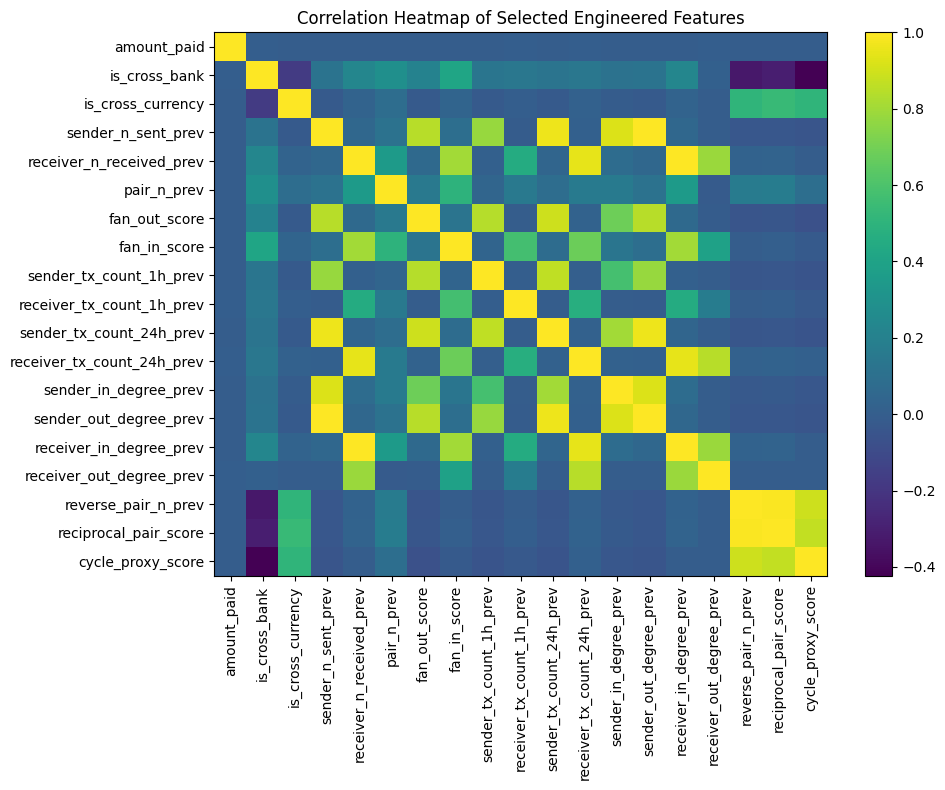

Saved: /home/acer/dev/aml-graph-dm/reports/figures/selected_graph_feature_correlation_heatmap.png


In [8]:
corr_cols = [c for c in available if c in df_features.columns]

if len(corr_cols) >= 2:
    corr = df_features[corr_cols].sample(min(100_000, len(df_features)), random_state=42).corr(numeric_only=True)
    display(corr)

    plt.figure(figsize=(10, 8))
    plt.imshow(corr.values, aspect="auto")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Heatmap of Selected Engineered Features")
    plt.colorbar()
    plt.tight_layout()

    out_path = FIGURES_DIR / "selected_graph_feature_correlation_heatmap.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path)
else:
    print("Not enough selected features for correlation heatmap.")

## 8. Leakage-prevention notes

Important methodology points for BAB III:
- Historical, rolling, centrality, and motif-proxy features are computed in timestamp order.
- A transaction only receives features derived from previous transactions.
- Snapshot PageRank/community was tested with past snapshots, but it did not improve the final model.
- Node2vec is trained later using only the chronological training graph, then embeddings are attached to validation/test rows. Validation/test edges are not used when learning node2vec vectors.